Mayah Carlton

# Homework 3

This Notebook builds on the unit commitment model introduced in [Notebook 5](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks) and the storage model introduced in [Notebook 2](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks).

First, load (or install if necessary) a set of packages you'll need for this assignment...

In [2]:
# Uncomment and run this first line if you need to install or update packages
#import Pkg; Pkg.add("JuMP"); Pkg.add("HiGHS"); Pkg.add("DataFrames"); Pkg.add("CSV"); Pkg.add("Plots"); Pkg.add("VegaLite")
using JuMP
using HiGHS
using DataFrames
using CSV
import Pkg; Pkg.add("PlotlyBase")
using Plots; plotly();
using VegaLite  # to make some nice plots

#=
Function to convert JuMP outputs (technically, AxisArrays) with two-indexes to a dataframe
Inputs:
    var -- JuMP AxisArray (e.g., value.(GEN))
Reference: https://jump.dev/JuMP.jl/v0.19/containers/
=#
function value_to_df_2dim(var)
    solution = DataFrame(var.data, :auto)
    ax1 = var.axes[1]
    ax2 = var.axes[2]
    cols = names(solution)
    insertcols!(solution, 1, :r_id => ax1)
    solution = stack(solution, Not(:r_id), variable_name=:hour)
    solution.hour = foldl(replace, [cols[i] => ax2[i] for i in 1:length(ax2)], init=solution.hour)
    rename!(solution, :value => :gen)
    solution.hour = convert.(Int64,solution.hour)
    return solution
end

    Updating registry at `~/.julia/registries/General.toml`
   Resolving package versions...
     Project No packages added to or removed from `~/power-systems-optimization/Project.toml`
    Manifest No packages added to or removed from `~/power-systems-optimization/Manifest.toml`
[ Info: Precompiling IJuliaExt [ca55ebba-d40a-59bc-9445-d114519c28be] 

SYSTEM: caught exception of type :MethodError while trying to print a failed Task notice; giving up
┌ Warning: Failed to load integration with PlotlyBase & PlotlyKaleido.
│   exception =
│    ArgumentError: Package PlotlyKaleido not found in current path.
│    - Run `import Pkg; Pkg.add("PlotlyKaleido")` to install the PlotlyKaleido package.
│    Stacktrace:
│      [1] macro expansion
│        @ ./loading.jl:2403 [inlined]
│      [2] macro expansion
│        @ ./lock.jl:376 [inlined]
│      [3] __require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:2386
│      [4] require(into::Module, mod::Symbol)
│        @ Base ./loading.jl:

value_to_df_2dim (generic function with 1 method)

## Question 1 - Compare startup costs in unit commitment

**A. Code and run basic model.**

Data for this problem is stored in [`Homeworks/hw3_data`](hw3_data/).

Following the `unit_commitment_simple` modeling formulation in [Notebook 5](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks), load the above data and create a unit commitment solver function with the following set of constraints:

- Demand balance
- Minimum / maximum generator constraints (non-committed)
- Minimum / maximum generator constraints (committed)
- Three-variable commitment formulation

Note: the data (with hours 1-24) is already in local time. Hence, do not convert from GMT to GMT-8.

Run the UC for the given day and plot a stacked area chart of generation using `@vlplot` from the `VegaLite` package.

Throughout this assignment, please use a relative MIP gap of 1% for all questions. (If you are having difficulty getting this to solve on your computer in a reasonble amount of time, you can relax the gap but please then specify clearly in your comments that you have done so.)

In [4]:

# load data from csv files
path = joinpath("..","Homeworks", "hw3_data")
generators = CSV.read(joinpath(path, "Generators_data.csv"), DataFrame)
loads = CSV.read(joinpath(path, "Demand.csv"), DataFrame)
gen_var = CSV.read(joinpath(path, "Generators_variability.csv"), DataFrame)
fuels = CSV.read(joinpath(path, "Fuels_data.csv"), DataFrame)

# lowercase everything for easier handling
for f in [generators, fuels, loads, gen_var]
    rename!(f,lowercase.(names(f)))
end
# simple unit commitment model (notebook 5)


In [5]:
# format the data for use in our unit commitment model
# Keep columns relevant to our UC model 
select!(generators, 1:26) # columns 1:26
gen_df = outerjoin(generators,  fuels, on = :fuel) # load in fuel costs and add to data frame
rename!(gen_df, :cost_per_mmbtu => :fuel_cost)   # rename column for fuel cost
gen_df.fuel_cost[ismissing.(gen_df[:,:fuel_cost])] .= 0

# create "is_variable" column to indicate if this is a variable generation source (e.g. wind, solar):
gen_df[!, :is_variable] .= false
gen_df[in(["onshore_wind_turbine","small_hydroelectric","solar_photovoltaic"]).(gen_df.resource),
    :is_variable] .= true;

# create full name of generator (including geographic location and cluster number)
#  for use with variable generation dataframe
gen_df.gen_full = lowercase.(gen_df.region .* "_" .* gen_df.resource .* "_" .* string.(gen_df.cluster) .* ".0");

# remove generators with no capacity (e.g. new build options that we'd use if this was capacity expansion problem)
gen_df = gen_df[gen_df.existing_cap_mw .> 0.0,:];

# reshape to "long" format
gen_variable_long = stack(gen_var, 
                        Not(:hour), 
                        variable_name=:gen_full,
                        value_name=:cf);
#


In [9]:
#= Notebook 5 function
Function to solve simple unit commitment problem (commitment equations)
Inputs:
    gen_df -- dataframe with generator info
    loads  -- load by time
    gen_variable -- capacity factors of variable generators (in "long" format)
    mip_gap -- desired relative MIP gap to pass to solver
=#
function unit_commitment_simple(gen_df, loads, gen_var, mip_gap)
    UC = Model(HiGHS.Optimizer)
    set_optimizer_attribute(UC, "mip_rel_gap", mip_gap)

    # Define sets based on data
    # Note the creation of several different sets of generators for use in
    # different equations.
        # Thermal resources for which unit commitment constraints apply
    G_thermal = gen_df[gen_df[!,:up_time] .> 0,:r_id] 
        # Non-thermal resources for which unit commitment constraints do NOT apply 
    G_nonthermal = gen_df[gen_df[!,:up_time] .== 0,:r_id]
        # Variable renewable resources
    G_var = gen_df[gen_df[!,:is_variable] .== 1,:r_id]
        # Non-variable (dispatchable) resources
    G_nonvar = gen_df[gen_df[!,:is_variable] .== 0,:r_id]
        # Non-variable and non-thermal resources
    G_nt_nonvar = intersect(G_nonvar, G_nonthermal)
        # Set of all generators (above are all subsets of this)
    G = gen_df.r_id
        # All time periods (hours) over which we are optimizing
    T = loads.hour
        # A subset of time periods that excludes the last time period
    T_red = loads.hour[1:end-1]  # reduced time periods without last one

    # Generator capacity factor time series for variable generators
    gen_var_cf = innerjoin(gen_var, 
                    gen_df[gen_df.is_variable .== 1 , 
                        [:r_id, :gen_full, :existing_cap_mw]], 
                    on = :gen_full)
        
    # Decision variables   
    @variables(UC, begin
            # Continuous decision variables
        GEN[G, T]  >= 0     # generation
            # Bin = binary variables; 
            # the following are all binary decisions that 
            # can ONLY take the values 0 or 1
            # The presence of these discrete decisions makes this an MILP
        COMMIT[G_thermal, T], Bin # commitment status (Bin=binary)
        START[G_thermal, T], Bin  # startup decision
        SHUT[G_thermal, T], Bin   # shutdown decision
    end)
                
    # Objective function
        # Sum of variable costs + start-up costs for all generators and time periods
    @objective(UC, Min, 
        sum( (gen_df[gen_df.r_id .== i,:heat_rate_mmbtu_per_mwh][1] * gen_df[gen_df.r_id .== i,:fuel_cost][1] +
            gen_df[gen_df.r_id .== i,:var_om_cost_per_mwh][1]) * GEN[i,t] 
                        for i in G_nonvar for t in T) + 
        sum(gen_df[gen_df.r_id .== i,:var_om_cost_per_mwh][1] * GEN[i,t] 
                        for i in G_var for t in T)  + 
        sum(gen_df[gen_df.r_id .== i,:start_cost_per_mw][1] * 
            gen_df[gen_df.r_id .== i,:existing_cap_mw][1] *
            START[i,t] 
                        for i in G_thermal for t in T)
    )
    
    # Demand balance constraint (supply must = demand in all time periods)
    @constraint(UC, cDemand[t in T], 
        sum(GEN[i,t] for i in G) == loads[loads.hour .== t,:demand][1])

    # Capacity constraints 
      # 1. thermal generators requiring commitment
    @constraint(UC, Cap_thermal_min[i in G_thermal, t in T], 
        GEN[i,t] >= COMMIT[i, t] * gen_df[gen_df.r_id .== i,:existing_cap_mw][1] *
                        gen_df[gen_df.r_id .== i,:min_power][1])
    @constraint(UC, Cap_thermal_max[i in G_thermal, t in T], 
        GEN[i,t] <= COMMIT[i, t] * gen_df[gen_df.r_id .== i,:existing_cap_mw][1])

      # 2. non-variable generation not requiring commitment
    @constraint(UC, Cap_nt_nonvar[i in G_nt_nonvar, t in T], 
        GEN[i,t] <= gen_df[gen_df.r_id .== i,:existing_cap_mw][1])
    
      # 3. variable generation, accounting for hourly capacity factor
    @constraint(UC, Cap_var[i in 1:nrow(gen_var_cf)], 
            GEN[gen_var_cf[i,:r_id], gen_var_cf[i,:hour] ] <= 
                        gen_var_cf[i,:cf] *
                        gen_var_cf[i,:existing_cap_mw])
    
    # Unit commitment constraints
      # 1. Minimum up time
    @constraint(UC, Startup[i in G_thermal, t in T],
        COMMIT[i, t] >= sum(START[i, tt] 
                        for tt in intersect(T,
                            (t-gen_df[gen_df.r_id .== i,:up_time][1]):t)))

      # 2. Minimum down time
    @constraint(UC, Shutdown[i in G_thermal, t in T],
        1-COMMIT[i, t] >= sum(SHUT[i, tt] 
                        for tt in intersect(T,
                            (t-gen_df[gen_df.r_id .== i,:down_time][1]):t)))
 
      # 3. Commitment state
    @constraint(UC, CommitmentStatus[i in G_thermal, t in T_red],
        COMMIT[i,t+1] - COMMIT[i,t] == START[i,t+1] - SHUT[i,t+1])
    
    # Solve statement (! indicates runs in place)
    optimize!(UC)

    # Generation solution and convert to data frame 
    # with our helper function defined above
    gen = value_to_df_2dim(value.(GEN))

    # Commitment status solution and convert to data frame
    commit = value_to_df_2dim(value.(COMMIT))

    # Calculate curtailment = available wind and/or solar output that 
    # had to be wasted due to operating constraints
    curtail = innerjoin(gen_var_cf, gen, on = [:r_id, :hour])
    curtail.curt = curtail.cf .* curtail.existing_cap_mw - curtail.gen
    
    # Return the solution parameters and objective
    return (
        gen,
        commit,
        curtail,
        cost = objective_value(UC),
        status = termination_status(UC)
    )

end

unit_commitment_simple (generic function with 1 method)

In [10]:
# solve for a spring day

T_period = 1:24

# High solar case: 3,500 MW
#gen_df_sens = copy(gen_df)
#gen_df_sens[gen_df_sens.resource .== "solar_photovoltaic",
#    :existing_cap_mw] .= 3500

loads_multi = loads[in.(loads.hour,Ref(T_period)),:]
gen_variable_multi = gen_variable_long[in.(gen_variable_long.hour,Ref(T_period)),:]

# Note we reduce the MIP gap tolerance threshold here to increase tractability
# Here we set it to a 1% gap (mip_gap=0.01), meaning that we will terminate once we have 
# a feasible integer solution guaranteed to be within 1% of the objective
# function value of the optimal solution (e.g. the upper and lower bound are within 1% of
# each other as HiGHS traverses the branch and bound tree).
# HiGHS's default MIP gap is 0.0001 (0.01%), which can take a longer time for 
# any complex problem. So it is important to set this to a realistic value.
# For a list of all solver options implemented via HiGHS.jl see 
# https://github.com/jump-dev/HiGHS.jl
solution = unit_commitment_simple(
    gen_df, loads_multi, gen_variable_multi, 0.01); #1% MIP Gap

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 2167 rows; 1752 cols; 6858 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2013 rows, 1707 cols, 6595 nonzeros  0s
1791 rows, 1423 cols, 7349 nonzeros  0s
Presolve reductions: rows 1791(-376); columns 1423(-329); nonzeros 7349(+491) 

Solving MIP model with:
   1791 rows
   1423 cols (968 binary, 0 integer, 0 implied int., 455 continuous, 0 domain fixed)
   7349 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; 

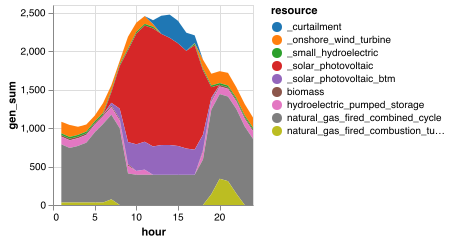

In [12]:
# Add in BTM solar and curtailment and plot results

sol_gen = innerjoin(solution.gen, 
                    gen_df[!, [:r_id, :resource]], 
                    on = :r_id)
sol_gen = combine(groupby(sol_gen, [:resource, :hour]), 
            :gen => sum)

# Rename generators (for plotting purposes)
sol_gen[sol_gen.resource .== "solar_photovoltaic", :resource] .= "_solar_photovoltaic"
sol_gen[sol_gen.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen[sol_gen.resource .== "small_hydroelectric", :resource] .= "_small_hydroelectric"

# Curtailment
curtail = combine(groupby(solution.curtail, [:hour]),
            :curt => sum)
curtail[!, :resource] .= "_curtailment"
rename!(curtail, :curt_sum => :gen_sum)
append!(sol_gen, curtail[:,[:resource, :hour, :gen_sum]])

# Rescale hours
#sol_gen.hour = sol_gen.hour .- T_period[1]

sol_gen |>
@vlplot(:area, 
    x=:hour, y={:gen_sum, stack=:zero}, 
    color={"resource:n", scale={scheme="category10"}})

**B. Zero startup costs sensitivity**

Next, create a modified version of the generator dataframe (`gen_df_sens = copy(gen_df)`) and set the startup costs for all generators to be 0.

Rerun the UC and compare with the first solution. What are the main differences and why?

In [44]:
# make new dataframe with 0 startup cost for all generators
gen_df_sens = copy(gen_df)
gen_df_sens[gen_df_sens.start_cost_per_mw .> 0, :start_cost_per_mw] .= 0

# rerun the model

solution = unit_commitment_simple(
    gen_df_sens, loads_multi, gen_variable_multi, 0.01); #1% MIP Gap

Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 2167 rows; 1752 cols; 6858 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [1e+00, 6e+02]
  Cost    [5e+00, 5e+01]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2013 rows, 1707 cols, 6595 nonzeros  0s
1791 rows, 1423 cols, 7349 nonzeros  0s
Presolve reductions: rows 1791(-376); columns 1423(-329); nonzeros 7349(+491) 

Solving MIP model with:
   1791 rows
   1423 cols (968 binary, 0 integer, 0 implied int., 455 continuous, 0 domain fixed)
   7349 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; 

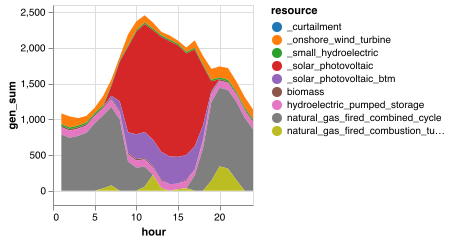

In [45]:
# and plot

sol_gen = innerjoin(solution.gen, 
                    gen_df[!, [:r_id, :resource]], 
                    on = :r_id)
sol_gen = combine(groupby(sol_gen, [:resource, :hour]), 
            :gen => sum)

# Rename generators (for plotting purposes)
sol_gen[sol_gen.resource .== "solar_photovoltaic", :resource] .= "_solar_photovoltaic"
sol_gen[sol_gen.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen[sol_gen.resource .== "small_hydroelectric", :resource] .= "_small_hydroelectric"

# BTM solar
btm = DataFrame(resource = repeat(["_solar_photovoltaic_btm"]; outer=length(T_period)), 
    hour = T_period,
    gen_sum = gen_variable_multi[gen_variable_multi.gen_full .== "wec_sdge_solar_photovoltaic_1.0",:cf] * 600)
append!(sol_gen, btm)

# Curtailment
curtail = combine(groupby(solution.curtail, [:hour]),
            :curt => sum)
curtail[!, :resource] .= "_curtailment"
rename!(curtail, :curt_sum => :gen_sum)
append!(sol_gen, curtail[:,[:resource, :hour, :gen_sum]])

# Rescale hours
#sol_gen.hour = sol_gen.hour .- T_period[1]

sol_gen |>
@vlplot(:area, 
    x=:hour, y={:gen_sum, stack=:zero}, 
    color={"resource:n", scale={scheme="category10"}})

Answer: The main differences in this formulation is that the natural gas generation is much more flexible. Removing the startup costs allows the generation to reflect the exact difference from the demand and generation from the free renewables. This also completely eliminates the curtailment since the generators don't need to run at a baseline. 

## Question 2: Implement pumped hydropower storage

In the data, we have a generator `hydroelectric_pumped_storage` which is a pumped hydro storage (PHS) facility. We have been treating it as a free resource, but in fact, it's a battery. 

The PHS equations for stored water are identical to the state of charge for the battery in Notebook 2:

\begin{align*} 
SOC_t = SOC_{t-1} + \big(CHARGE_t * battery\_eff - \frac{DISCHARGE_t}{battery\_eff}\big)  \quad \forall t \in T
\end{align*}

In addition, the PHS has a power capacity constraint given in the dataframe's `existing_cap_mw` variable. You will also need to implement an energy capacity constraint. 

**A. Code pumped hydropower storage constraints.**

Copy the `unit_commitment_simple` code above into a new cell below and rename the function `unit_commitment_storage`.

Reviewing [Notebook 2](https://github.com/east-winds/power-systems-optimization/tree/master/Notebooks), add in relevant constraints for charging and discharging pumped hydropower. Assume the following parameters:

- One-way efficiency is $battery_{eff} = 0.84$ (i.e., round-trip efficiency = $0.7$)
- Energy capacity = 4 x Power capacity
- Stored energy starts and ends the day at 50% capacity (you will need to code these constraints)

Indicate which equations and variables you have added and explain your steps using inline code comments (e.g. `# Comment`).

In [63]:
# ADD: used to show my addition to the unit_commitment_storage function with pumped hydropower storage constraints

function unit_commitment_storage(gen_df, loads, gen_var, mip_gap)
    UC = Model(HiGHS.Optimizer)
    set_optimizer_attribute(UC, "mip_rel_gap", mip_gap)

    # Define sets based on data
    # Note the creation of several different sets of generators for use in
    # different equations.
        # Thermal resources for which unit commitment constraints apply
    G_thermal = gen_df[gen_df[!,:up_time] .> 0,:r_id] 
        # Non-thermal resources for which unit commitment constraints do NOT apply 
    G_nonthermal = gen_df[gen_df[!,:up_time] .== 0,:r_id]
        # Variable renewable resources
    G_var = gen_df[gen_df[!,:is_variable] .== 1,:r_id]
        # Non-variable (dispatchable) resources
    G_nonvar = gen_df[gen_df[!,:is_variable] .== 0,:r_id]
        # Non-variable and non-thermal resources
    G_nt_nonvar = intersect(G_nonvar, G_nonthermal)
        # ADD: Pumped hydro storage resources
    G_storage = gen_df[gen_df.resource .== "hydroelectric_pumped_storage", :r_id] # we need to separate the hydroelectric so that we can apply different sets of constraints
        # Set of all generators (above are all subsets of this)
    G = gen_df.r_id
        # All time periods (hours) over which we are optimizing
    T = loads.hour
        # A subset of time periods that excludes the last time period
    T_red = loads.hour[1:end-1]  # reduced time periods without last one

    # Generator capacity factor time series for variable generators
    gen_var_cf = innerjoin(gen_var, 
                    gen_df[gen_df.is_variable .== 1 , 
                        [:r_id, :gen_full, :existing_cap_mw]], 
                    on = :gen_full)
        
    # ADD: include battery parameters for PHS
    battery_eff = 0.84  # battery efficiency (given)
    energy_cap_factor = 4  # energy capacity = 4 x power capacity (given)
    
    # Decision variables   
    @variables(UC, begin
            # Continuous decision variables
        GEN[G, T]  >= 0     # generation (for PHS, this is discharge)
        #ADD: decision variables for PHS charging, discharging, and the state of charge of the PHS battery
        CHARGE[G_storage, T] >= 0  # charging PHS (always >=0))
        DISCHARGE[G_storage, T] >= 0  # discharging PHS
        SOC[G_storage, T] >= 0  # state of charge for PHS
            # Bin = binary variables; 
            # the following are all binary decisions that 
            # can ONLY take the values 0 or 1
            # The presence of these discrete decisions makes this an MILP
        COMMIT[G_thermal, T], Bin # commitment status (Bin=binary)
        START[G_thermal, T], Bin  # startup decision
        SHUT[G_thermal, T], Bin   # shutdown decision
    end)
                
    # Objective function
        # Sum of variable costs + start-up costs for all generators and time periods
        # ADD: no change, the PHS has no variable or fuel costs
    @objective(UC, Min, 
        sum( (gen_df[gen_df.r_id .== i,:heat_rate_mmbtu_per_mwh][1] * gen_df[gen_df.r_id .== i,:fuel_cost][1] +
            gen_df[gen_df.r_id .== i,:var_om_cost_per_mwh][1]) * GEN[i,t] 
                        for i in G_nonvar for t in T) + 
        sum(gen_df[gen_df.r_id .== i,:var_om_cost_per_mwh][1] * GEN[i,t] 
                        for i in G_var for t in T)  + 
        sum(gen_df[gen_df.r_id .== i,:start_cost_per_mw][1] * 
            gen_df[gen_df.r_id .== i,:existing_cap_mw][1] *
            START[i,t] 
                        for i in G_thermal for t in T)
    )
    
    # Demand balance constraint (supply must = demand in all time periods)
    # ADD: charging "takes away" demand
    @constraint(UC, cDemand[t in T], 
        sum(GEN[i,t] for i in G) - sum(CHARGE[i,t] for i in G_storage) == loads[loads.hour .== t,:demand][1])

    # Capacity constraints 
      # 1. thermal generators requiring commitment
    @constraint(UC, Cap_thermal_min[i in G_thermal, t in T], 
        GEN[i,t] >= COMMIT[i, t] * gen_df[gen_df.r_id .== i,:existing_cap_mw][1] *
                        gen_df[gen_df.r_id .== i,:min_power][1])
    @constraint(UC, Cap_thermal_max[i in G_thermal, t in T], 
        GEN[i,t] <= COMMIT[i, t] * gen_df[gen_df.r_id .== i,:existing_cap_mw][1])

      # 2. non-variable generation not requiring commitment
    @constraint(UC, Cap_nt_nonvar[i in G_nt_nonvar, t in T], 
        GEN[i,t] <= gen_df[gen_df.r_id .== i,:existing_cap_mw][1])
    
      # 3. variable generation, accounting for hourly capacity factor
    @constraint(UC, Cap_var[i in 1:nrow(gen_var_cf)], 
            GEN[gen_var_cf[i,:r_id], gen_var_cf[i,:hour] ] <= 
                        gen_var_cf[i,:cf] *
                        gen_var_cf[i,:existing_cap_mw])
    
      # ADD: PHS power capacity constraints
    @constraint(UC, PHS_power[i in G_storage, t in T], 
        DISCHARGE[i,t] <= gen_df[gen_df.r_id .== i,:existing_cap_mw][1]) # the discharge rate of the PHS is limited by the power capacity
    @constraint(UC, PHS_charge_power[i in G_storage, t in T], 
        CHARGE[i,t] <= gen_df[gen_df.r_id .== i,:existing_cap_mw][1]) # the charge rate of the PHS is also limited by the power capacity
    
      # ADD: PHS energy capacity constraint
    @constraint(UC, PHS_energy[i in G_storage, t in T], 
        SOC[i,t] <= energy_cap_factor * gen_df[gen_df.r_id .== i,:existing_cap_mw][1]) # the total energy that can be stored is 4 X the power capacity (given)
    
      # ADD: PHS SOC equations
    @constraint(UC, PHS_SOC_start[i in G_storage], 
        SOC[i, T[1]] == 0.5 * energy_cap_factor * gen_df[gen_df.r_id .== i,:existing_cap_mw][1])  # start the day at 50% capacity
    @constraint(UC, PHS_SOC_dynamics[i in G_storage, t in T_red], 
        SOC[i, t+1] == SOC[i, t] + CHARGE[i, t+1] * battery_eff - DISCHARGE[i, t+1] / battery_eff) #the state of charge is subject to the previous state of charge value and the charge and discharge decisions times the efficiency
    @constraint(UC, PHS_SOC_end[i in G_storage], 
        SOC[i, T[end]] == 0.5 * energy_cap_factor * gen_df[gen_df.r_id .== i,:existing_cap_mw][1])  # end the day at 50% capacity
    
      # ADD: let PHS generation = discharge for the objective function and demand balance constraint
    @constraint(UC, PHS_gen_link[i in G_storage, t in T], 
        GEN[i,t] == DISCHARGE[i,t]) # the generation from the PHS is equal to the discharge of the PHS ei. electricity is generated when the system is discharging
    
    # Unit commitment constraints
      # 1. Minimum up time
    @constraint(UC, Startup[i in G_thermal, t in T],
        COMMIT[i, t] >= sum(START[i, tt] 
                        for tt in intersect(T,
                            (t-gen_df[gen_df.r_id .== i,:up_time][1]):t)))

      # 2. Minimum down time
    @constraint(UC, Shutdown[i in G_thermal, t in T],
        1-COMMIT[i, t] >= sum(SHUT[i, tt] 
                        for tt in intersect(T,
                            (t-gen_df[gen_df.r_id .== i,:down_time][1]):t)))
 
      # 3. Commitment state
    @constraint(UC, CommitmentStatus[i in G_thermal, t in T_red],
        COMMIT[i,t+1] - COMMIT[i,t] == START[i,t+1] - SHUT[i,t+1])
    
    # Solve statement (! indicates runs in place)
    optimize!(UC)

    # Generation solution and convert to data frame 
    # with our helper function defined above
    gen = value_to_df_2dim(value.(GEN))

    # Commitment status solution and convert to data frame
    commit = value_to_df_2dim(value.(COMMIT))

    # ADD: get the charge and discharge decision variables for PHS and convert to data frames (like above)
    charge = value_to_df_2dim(value.(CHARGE))
    discharge = value_to_df_2dim(value.(DISCHARGE))

    # Calculate curtailment = available wind and/or solar output that 
    # had to be wasted due to operating constraints
    curtail = innerjoin(gen_var_cf, gen, on = [:r_id, :hour])
    curtail.curt = curtail.cf .* curtail.existing_cap_mw - curtail.gen
    
    # Return the solution parameters and objective
    return (
        gen,
        commit,
        curtail,
        charge,  #ADD: return the charge decision variable
        discharge, #ADD: return the discharge decision variable
        cost = objective_value(UC),
        status = termination_status(UC)
    )

end

unit_commitment_storage (generic function with 1 method)

**B. Solve the new UC with PHS and plot.**

Using the above formulation, solve for the same parameters in Problem 1 and plot. For the purposes of plotting, you will want to create two resources&mdash;PHS_charge and PHS_discharge. By convention, you could put PHS_charge on top to indicate this is increasing system load.

In [64]:
solution = unit_commitment_storage(
    gen_df, loads_multi, gen_variable_multi, 0.01);



Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 2288 rows; 1824 cols; 7096 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+03]
Presolving model
2036 rows, 1753 cols, 6709 nonzeros  0s
1808 rows, 1486 cols, 7464 nonzeros  0s
Presolve reductions: rows 1808(-480); columns 1486(-338); nonzeros 7464(+368) 

Solving MIP model with:
   1808 rows
   1486 cols (964 binary, 0 integer, 0 implied int., 522 continuous, 0 domain fixed)
   7464 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; 

In [65]:
sol_gen = innerjoin(solution.gen, 
                    gen_df[!, [:r_id, :resource]], 
                    on = :r_id)
sol_gen = combine(groupby(sol_gen, [:resource, :hour]), 
            :gen => sum)

# Rename generators (for plotting purposes)
sol_gen[sol_gen.resource .== "solar_photovoltaic", :resource] .= "_solar_photovoltaic"
sol_gen[sol_gen.resource .== "onshore_wind_turbine", :resource] .= "_onshore_wind_turbine"
sol_gen[sol_gen.resource .== "small_hydroelectric", :resource] .= "_small_hydroelectric"
sol_gen[sol_gen.resource .== "hydroelectric_pumped_storage", :resource] .= "phs_discharge" # add the PHS discharge as a generation resource for plotting

# ADD: PHS charge as an additional stacked area series 
battery_charge = solution.charge # collect the charge decision variable 
battery_charge[!, :resource] .= "__phs_charge" # rename the resource for plotting (underscores to make it appear at the top of the plot)
battery_charge = select(battery_charge, [:resource, :hour, :gen_sum])

append!(sol_gen, battery_charge) #add the PHS charge to the generation dataframe for plotting

# Curtailment
curtail = combine(groupby(solution.curtail, [:hour]),
            :curt => sum)
curtail[!, :resource] .= "_curtailment"
rename!(curtail, :curt_sum => :gen_sum)
append!(sol_gen, curtail[:,[:resource, :hour, :gen_sum]])

sol_gen |>
@vlplot(:area, 
    x=:hour, y={:gen_sum, stack=:zero}, 
    color={"resource:n", scale={scheme="category10"}})

LoadError: ArgumentError: column name :gen_sum not found in the data frame

**C. Interpret results**

Answer with a few sentences each of the following:

1. Compare your results to `unit_commitment_simple`. Have any commitments changed?

2. Interpret what is happening with the PHS facility during the day in terms of charging and discharging.

3. Has curtailment reduced? (Explain this in the context of the PHS operation.)

In [ ]:
1. The commitments have changed between the scenarios. The addition of storage eliminates the curtailment of the renewables by allowing the excess energy to be stored.The overall sum of the generation also decreases because adding batteries effectively helps flatten the demand which means less generation is required at peak times. The natural gas generation combined cycle is allowed to run at baseload with less ramping.
2. The PHS charge is mostly occuring where the curtailment is high, this is because at this part of the day, a portion of the curtailment is going toward charging the battery.  The discharge of the PHS is mirroring the natural gas combustion because this is where the difference in demand and renewable generation grows. The PHS discharges to help meet the demand at these times.
3. The total curtailment has decreased because the battery is able to store some of the excess renewable energy that would have been curtailed.

Question 3: LLM Exercise
Now, let us explore exactly how much pumped hydropower storage would be needed to completely
eliminate the need for fossil fuels in this system. First, we need to increase solar capacity to ensure
there is enough energy on the system. Use 10,000 MW of solar for this problem. Next, use a
suitable LLM to explore this sensitivity. Create a new section at the end of your Homework 3
notebook titled “Question 3: LLM Exercise”. Include the LLM prompts used (as markdown text
cells in your notebook) and ensure all code is replicated in the notebook (i.e., do not have the LLM
run the code or perform any computation outside of the notebook).

a) Evaluate the capacity of pumped hydropower storage when gas generation (across all the
generators) reaches 0. Plot the gas generation vs pumped hydropower storage capacity.

b) Show solar curtailment percentage for the final system and plot dispatch. Does this seem
cost-effective for a 2 GW peak demand system?

Answer: I copied the notebook file to claude and fed it the exact question 3 prompt. Part a ran immediately however to get part b to run I had to copy the error that the code gave me when I ran it and prompt it to change the code based on the error produced.

In [ ]:
# ── Question 3a: Sensitivity sweep — Gas Generation vs PHS Capacity ──────────

using Plots

# Step 1: Set solar capacity to 10,000 MW
gen_df_q3 = copy(gen_df)
gen_df_q3[gen_df_q3.resource .== "solar_photovoltaic", :existing_cap_mw] .= 10000.0

# Step 2: Identify gas generator r_ids
gas_resources = ["natural_gas_fired_combined_cycle", "natural_gas_fired_combustion_turbine"]
gas_ids = gen_df_q3[in.(gen_df_q3.resource, Ref(gas_resources)), :r_id]

println("Gas generator r_ids: ", gas_ids)

# Step 3: Sweep PHS capacity
phs_capacities = collect(500:500:10000)  # 500 MW to 10,000 MW in steps of 500

total_gas_gen = Float64[]

for phs_mw in phs_capacities
    println("Solving with PHS = $phs_mw MW...")
    
    # Modify PHS capacity in a fresh copy
    gen_df_run = copy(gen_df_q3)
    gen_df_run[gen_df_run.resource .== "hydroelectric_pumped_storage", :existing_cap_mw] .= Float64(phs_mw)
    
    result = unit_commitment_storage(gen_df_run, loads_multi, gen_variable_multi, 0.01)
    
    # Sum gas generation across all gas generators and all hours
    gas_gen_df = result[1]  # gen is the first element of the returned tuple
    gas_rows = gas_gen_df[in.(gas_gen_df.r_id, Ref(gas_ids)), :]
    total_gas = sum(gas_rows.gen)
    push!(total_gas_gen, total_gas)
    
    println("  Total gas generation: $(round(total_gas, digits=1)) MWh")
end

# Step 4: Find the PHS capacity where gas first reaches ~0
zero_idx = findfirst(total_gas_gen .< 1.0)
zero_gas_phs = isnothing(zero_idx) ? NaN : phs_capacities[zero_idx]

if isnan(zero_gas_phs)
    println("\nGas did not reach 0 within the swept range — extend upper bound!")
else
    println("\nGas reaches ~0 at PHS capacity: $zero_gas_phs MW")
end

# Step 5: Plot
p1 = plot(phs_capacities, total_gas_gen,
    xlabel  = "PHS Power Capacity (MW)",
    ylabel  = "Total Gas Generation (MWh)",
    title   = "Gas Generation vs. PHS Capacity\n(Solar = 10,000 MW)",
    lw      = 2,
    marker  = :circle,
    color   = :steelblue,
    legend  = false)

if !isnan(zero_gas_phs)
    vline!([zero_gas_phs], lw=2, ls=:dash, color=:red,
           label="Gas ≈ 0 @ $(zero_gas_phs) MW")
end

display(p1)

Gas generator r_ids: Union{Missing, Int64}[3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]
Solving with PHS = 500 MW...
Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 2288 rows; 1824 cols; 7096 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 6e+03]
Presolving model
2036 rows, 1753 cols, 6709 nonzeros  0s
1808 rows, 1475 cols, 7453 nonzeros  0s
Presolve reductions: rows 1808(-480); columns 1475(-349); nonzeros 7453(+357) 

Solving MIP model with:
   1808 rows
   1475 cols (964 binary, 0 integer, 0 implied int., 511 continuous, 0 domain fixed)
   7453 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U =>

In [ ]:
# ── Question 3b: Final no-gas system — curtailment and dispatch ───────────────

gen_df_final = copy(gen_df_q3)
gen_df_final[gen_df_final.resource .== "hydroelectric_pumped_storage",
             :existing_cap_mw] .= Float64(zero_gas_phs)

result_final = unit_commitment_storage(gen_df_final, loads_multi, gen_variable_multi, 0.01)

# ── Solar curtailment ─────────────────────────────────────────────────────────
total_available = sum(result_final.curtail.cf .* result_final.curtail.existing_cap_mw)
total_curtailed  = sum(result_final.curtail.curt)
curtailment_pct  = 100.0 * total_curtailed / total_available

println("Solar curtailment: $(round(curtailment_pct, digits=1))%")
println("Total curtailed:   $(round(total_curtailed, digits=0)) MWh")
println("Total available:   $(round(total_available, digits=0)) MWh")

# ── Build hourly generation vectors ──────────────────────────────────────────
hours = sort(unique(result_final[1].hour))

function hourly_gen(gen_df_out, ids, hrs)
    [sum(gen_df_out[(in.(gen_df_out.r_id, Ref(ids))) .& (gen_df_out.hour .== h), :gen],
         init=0.0) for h in hrs]
end

solar_ids   = gen_df_final[gen_df_final.resource .== "solar_photovoltaic", :r_id]
wind_ids    = gen_df_final[gen_df_final.resource .== "onshore_wind_turbine", :r_id]
hydro_ids   = gen_df_final[gen_df_final.resource .== "small_hydroelectric", :r_id]
biomass_ids = gen_df_final[gen_df_final.resource .== "biomass", :r_id]
phs_ids     = gen_df_final[gen_df_final.resource .== "hydroelectric_pumped_storage", :r_id]

gen_out = result_final[1]

solar_vec   = hourly_gen(gen_out, solar_ids,   hours)
wind_vec    = hourly_gen(gen_out, wind_ids,     hours)
hydro_vec   = hourly_gen(gen_out, hydro_ids,    hours)
biomass_vec = hourly_gen(gen_out, biomass_ids,  hours)
phs_dis_vec = hourly_gen(gen_out, phs_ids,      hours)

phs_chg_vec = [sum(result_final.charge[
                   (in.(result_final.charge.r_id, Ref(phs_ids))) .&
                   (result_final.charge.hour .== h), :gen],
               init=0.0) for h in hours]

demand_vec = [loads_multi[loads_multi.hour .== h, :demand][1] for h in hours]

# ── Dispatch stack plot ───────────────────────────────────────────────────────
# Build as separate filled series to avoid the adjoint/color transpose issue
dispatch_matrix = hcat(biomass_vec, hydro_vec, wind_vec, solar_vec, phs_dis_vec)
dispatch_labels = ["Biomass" "Small Hydro" "Wind" "Solar" "PHS Discharge"]
dispatch_colors = [:saddlebrown :dodgerblue :forestgreen :gold :teal]

p2 = plot(hours, dispatch_matrix,
    seriestype  = :steppost,   # use :line if you prefer smooth
    fillrange   = 0,
    fillalpha   = 0.6,
    label       = dispatch_labels,
    linecolor   = dispatch_colors,
    fillcolor   = dispatch_colors,
    xlabel      = "Hour",
    ylabel      = "Generation (MW)",
    title       = "Dispatch Stack — No-Gas System\n" *
                  "PHS = $(zero_gas_phs) MW | Solar = 10,000 MW | " *
                  "Curtailment = $(round(curtailment_pct, digits=1))%",
    legend      = :topright)

plot!(hours, demand_vec,   lw=2, color=:black, ls=:dash, label="Demand")
plot!(hours, -phs_chg_vec, lw=2, color=:red,   ls=:dot,  label="PHS Charging (−)")

display(p2)

# ── Cost-effectiveness commentary ─────────────────────────────────────────────
println("""
  Solar curtailment: $(round(curtailment_pct, digits=1))%
""")


Running HiGHS 1.13.1 (git hash: 1d267d97c): Copyright (c) 2026 under Apache 2.0 license terms
Using BLAS: blastrampoline 
MIP has 2288 rows; 1824 cols; 7096 nonzeros; 1224 integer variables (1224 binary)
Coefficient ranges:
  Matrix  [8e-01, 6e+02]
  Cost    [5e+00, 5e+04]
  Bound   [1e+00, 1e+00]
  RHS     [1e+00, 2e+04]
Presolving model
2036 rows, 1753 cols, 6709 nonzeros  0s
1807 rows, 1481 cols, 7442 nonzeros  0s
Presolve reductions: rows 1807(-481); columns 1481(-343); nonzeros 7442(+346) 

Solving MIP model with:
   1807 rows
   1481 cols (964 binary, 0 integer, 0 implied int., 517 continuous, 0 domain fixed)
   7442 nonzeros

Src: B => Branching; C => Central rounding; F => Feasibility pump; H => Heuristic;
     I => Shifting; J => Feasibility jump; L => Sub-MIP; P => Empty MIP; R => Randomized rounding;
     S => Solve LP; T => Evaluate node; U => Unbounded; X => User solution; Y => HiGHS solution;
     Z => ZI Round; l => Trivial lower; p => Trivial point; u => Trivial upper; 

  Solar curtailment: 31.6%



Answer: The solar curtailment is 31.6 %. This solution is not cost effective, there is significant overbuilding in the system to account for the variability of the resources during the off time.